# FCFNN in Google Colab

This notebook trains a fully connected feedforward neural network for binary classification using the Breast Cancer dataset.

**Speaker hint:** This is the simplest neural network in today's session and is best for structured table-like data.

In [ ]:
%pip install -q tensorflow scikit-learn matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Fix the random seed so results are more repeatable in the demo.
keras.utils.set_random_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU devices: []


In [ ]:
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
print(dataset)

# Split into train and test sets.
# Train data teaches the model. Test data checks generalization.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('Class names  :', dataset.target_names)


{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [ ]:
# Build a fully connected neural network.
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    # Dense means every neuron connects to every neuron in the next layer.
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    # Sigmoid is used because this is binary classification.
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
callbacks = [
    # Stop early if validation loss stops improving.
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    ),
    # Reduce the learning rate when progress slows down.
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
]

# model.fit() is the learning phase.
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6621 - loss: 0.6839 - val_accuracy: 0.6484 - val_loss: 0.5943 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8626 - loss: 0.3625 - val_accuracy: 0.8901 - val_loss: 0.4733 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8929 - loss: 0.3020 - val_accuracy: 0.9121 - val_loss: 0.3916 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9368 - loss: 0.2205 - val_accuracy: 0.9341 - val_loss: 0.3327 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9176 - loss: 0.2063 - val_accuracy: 0.9341 - val_loss: 0.2852 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9478 - loss: 0.1747 - val_accuracy: 0.9560 - val_loss: 0.2470 - learning_rate: 0.0010
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9505 - loss: 0.1541 - val_acc

## 5. What To Do After Training

Training is not the end of the demo. After training, you should show:

- performance on unseen test data
- what kinds of mistakes the model makes
- example predictions on individual samples


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

y_pred_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

print('\nClassification report')
print(classification_report(y_test, y_pred, target_names=dataset.target_names))
print('Confusion matrix')
print(confusion_matrix(y_test, y_pred))


Test accuracy: 0.9474
Test loss: 0.0834

Classification report
              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion matrix
[[40  2]
 [ 4 68]]


In [ ]:
sample_indices = [0, 1, 2, 3, 4]
sample_probs = model.predict(X_test[sample_indices], verbose=0).ravel()

for idx, prob in zip(sample_indices, sample_probs):
    predicted = dataset.target_names[int(prob >= 0.5)]
    actual = dataset.target_names[y_test[idx]]
    print(f'Sample {idx}: predicted={predicted:>9} | actual={actual:>9} | probability={prob:.4f}')


Sample 0: predicted=malignant | actual=malignant | probability=0.0002
Sample 1: predicted=   benign | actual=   benign | probability=0.9996
Sample 2: predicted=malignant | actual=malignant | probability=0.0087
Sample 3: predicted=malignant | actual=   benign | probability=0.4409
Sample 4: predicted=malignant | actual=malignant | probability=0.0000


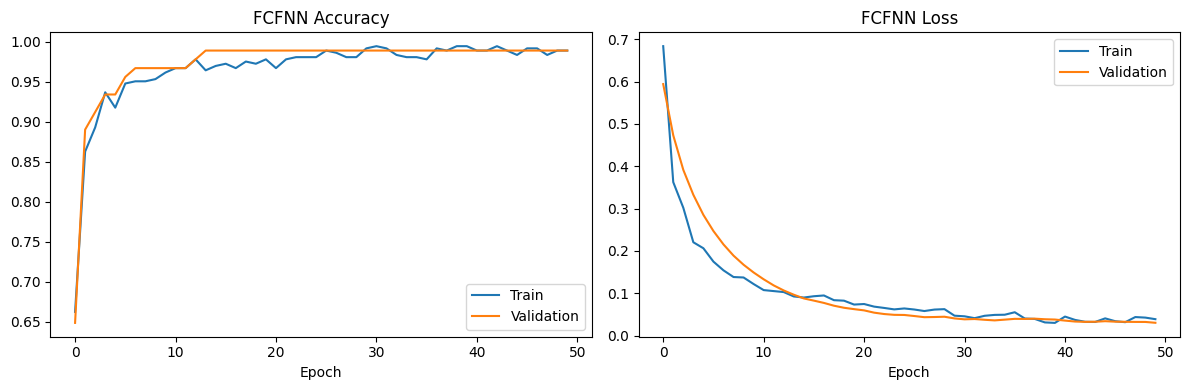

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('FCFNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('FCFNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Summary:

- We trained a neural network on structured input features.
- We evaluated it on unseen data instead of trusting training results alone.
- We inspected example predictions to connect the model to practical use.
- This is the full workflow: build, train, evaluate, predict, save.


In [ ]:
model.save('fcfnn_breast_cancer.keras')
print('Saved model to fcfnn_breast_cancer.keras')


Saved model to fcfnn_breast_cancer.keras
